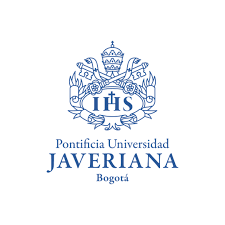

***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Métricas y Machine Learning con PySpark**

Autor: Sara Mejia Giraldo

Fecha de Inicio: 28/04/2026

## **Metodologia**

- Cargar Sesion Spark
- Cargar datos de Banca
- Limpiar Datos


# **1. Preparacion**

## 1.1. Levantamiento de variables de entorno pip

In [1]:
## Importa las bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Bibliotecas especializadas PySpark
from pylab import *

import findspark
findspark.init()

import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc

## 1.2. Levantamiento Sesion Spark
Se trabajó con DataFrames de Spark, una estructura de datos optimizada que facilita tareas de exploración, limpieza, transformación y análisis de grandes volúmenes de información de forma eficiente, aprovechando los recursos del clúster y mejorando el rendimiento frente a métodos tradicionales.

In [2]:
### se requiere levantar la sesion 
configura = SparkConf()
configura.set("spark.scheduler.mode", "FAIR")
configura.set("spark.scheduler.allocation", "/Almacen/Spark/conf/fairscheduler.xml ")
configura.setMaster("spark://10.43.97.171:7077")
configura.setAppName("Banca_Mejia_Spark")

sparkMejia = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext=sparkMejia.sparkContext, sparkSession=sparkMejia)
sparkContextoMejia = sparkMejia.sparkContext.getOrCreate()

sparkMejia

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/06 14:23:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1.3. Carga de Datos desde el HADOOP HDFS

Hadoop Distributed File System (HDFS) es el sistema de archivos distribuido de Apache Hadoop. Está diseñado para almacenar grandes volúmenes de datos en varias máquinas de un clúster de forma simultánea. Se destaca por su alta tolerancia a fallos y por su escalabilidad.

A continuación, se utiliza Apache Spark para leer el archivo en formato CSV almacenado en HDFS y cargarlo en un DataFrame de Spark.

In [3]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv
### se carga el dataset a un objeto dataframe 
df00 = sparkMejia.read.format("csv").option("header", "true").option("sep", ";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv")

df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

# **2. Análisis y Preparación de Datos**

## 2.1. Columnas: conocimiento de las columnas, eliminación

In [4]:
### conocimiento de las columnas
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| age | Feature | Integer | Age | Edad del cliente. |  | no |
| job | Feature | Categorical | Occupation | Tipo de trabajo: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`. |  | no |
| marital | Feature | Categorical | Marital Status | Estado civil: `divorced`, `married`, `single`, `unknown`. Nota: `divorced` incluye personas divorciadas o viudas. |  | no |
| education | Feature | Categorical | Education Level | Nivel educativo: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`. |  | no |
| default | Feature | Binary |  | Indica si el cliente tiene crédito en mora/incumplimiento. |  | no |
| balance | Feature | Integer |  | Saldo promedio anual. | euros | no |
| housing | Feature | Binary |  | Indica si el cliente tiene crédito de vivienda. |  | no |
| loan | Feature | Binary |  | Indica si el cliente tiene préstamo personal. |  | no |
| contact | Feature | Categorical |  | Tipo de comunicación de contacto: `cellular`, `telephone`. |  | yes |
| day_of_week | Feature | Date |  | Día de la semana del último contacto. |  | no |
| month | Feature | Date |  | Mes del último contacto: `jan`, `feb`, `mar`, ..., `nov`, `dec`. |  | no |
| duration | Feature | Integer |  | Duración del último contacto, en segundos (númerica). Nota: esta variable afecta directamente la variable target (y), puesto que si la duracion es 0 entonces y=no. Por lo tanto, este dato solo debe incluirse con fines comparativos y debe descartarse si la intención es obtener un modelo predictivo realista.|  | no |
| campaign | Feature | Integer |  | Cantidad de contactos durante esta campaña, para este cliente |  | no |
| pdays | Feature | Integer |  | Cantidad de dias que pasaron desde que el cliente fue contactado por ultima vez. (Un valor de -1 indica que el cliente no fue contactado previamente) |  | yes |
| previous | Feature | Integer |  | Cantidad de contactos hechos antes de esta campaña, para este cliente |  | no |
| poutcome | Feature | Integer |  | Resultado de la campaña de marketing previa: `failure`, `nonexistent`, `success` |  | yes |
| y | Target | Binary |  | El cliente se ha suscrito a un deposito a plazo |  | yes |

#### Observaciones:
Debido a que el proposito de este análisis es obtener un modelo predicitvo, se propone eliminar la variable `duration`

## 2.2. Tipos de datos: coherencia de tipo de datos, transformacion
Para garantizar la calidad y consistencia de la base de datos, se realizó una revisión y ajuste de los tipos de datos de cada variable.

In [5]:
### mostrar la cantidad de datos en el dataset
cantidad_datos = df00.count()
print("Cantidad de datos:", cantidad_datos)

[Stage 2:=============================>                             (1 + 1) / 2]

Cantidad de datos: 45211


### 2.2.1. Revisión inicial de la estructura:
Mediante la función printSchema() de Apache Spark se inspeccionó el esquema inicial del DataFrame. En esta primera validación se identificó que todas las columnas habían sido cargadas como tipo string.

In [6]:
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



#### COMENTARIOS
- Todos los datos se encuentran en tipo string
- Se identifica el cambio a entero o double
- Age, Balance, Duration, campaign, pdays, previous deberian ser enteros
- Se observa que la ultima columna es la columna TARGET
- se propone eliminar DURATION

### 2.2.2. Definición de tipos esperados:
Con base en la naturaleza de cada variable, se determinó la estructura correcta de los datos:
- `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous` deben ser de tipo enteros.

#### COMENTARIOS:
- Se observa el tratamiento para transformar a datos númericos con coherencia
- Tener en cuenta que la visualizacion al usar dataframe pandas debe ser para objetos pequeños

### 2.2.3. Transformación de variables:
**Se cambio el nombre de la variable y.** Luego, se aplicó el proceso de casting o conversión de tipos de datos, asignando a cada columna el formato correspondiente. Esto permitió dejar la base preparada para análisis estadísticos, cálculos numéricos y validaciones posteriores, evitando errores derivados de trabajar variables numéricas como texto.

In [7]:
### df01 = df00.withColumnRenamed('y', 'STATION_CODE')

In [8]:
# cambio de string a enteros
df01 = df00.withColumn("age", df00.age.cast("int"))
df01 = df01.withColumn("balance", df01.balance.cast("int"))
df01 = df01.withColumn("day", df01.day.cast("int"))
df01 = df01.withColumn("duration", df01.duration.cast("int"))
df01 = df01.withColumn("campaign", df01.campaign.cast("int"))
df01 = df01.withColumn("pdays", df01.pdays.cast("int"))
df01 = df01.withColumn("previous", df01.previous.cast("int"))

### 2.3. Visualizacion de datos nulos

In [54]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

[Stage 64:=============================>                            (1 + 1) / 2]

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



**No hay datos nulos (elaborar)**

### 2.4. Estadisticas Descriptivas

Primero, se realizó una revisión preliminar mediante estadísticos descriptivos, grafico circular, histogramas, diagramas de caja y bigotes con el fin de identificar valores atípicos, dispersión y posibles inconsistencias en las variables. Lueo, se trabajo en encontrar las variables que inciden en la variable target. 



In [9]:
# se revisa el balance del dataset. La idea es conocer si hay posibilidades de sesgo
total = df01.count()
df_Y = df01. groupBy("y").count()
auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)
auxPD.show()

[Stage 8:>                                                          (0 + 2) / 2]

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



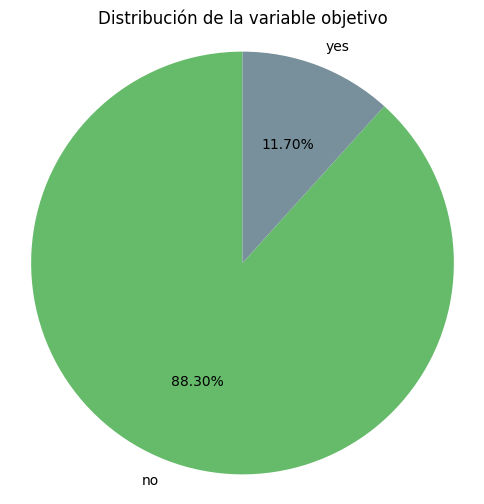

In [50]:
colores = ["#66BB6A", "#78909C"]  # yes, no

plt.figure(figsize=(6,6))
plt.pie(
    df_balance["count"],
    labels=df_balance["y"],
    autopct="%1.2f%%",
    startangle=90,
    colors=colores
)

plt.title("Distribución de la variable objetivo")
plt.axis("equal")
plt.show()

#### OBSERVACIONES SESGO:
Existe un sesgo en la base de datos ya que casi el 90% de los registros de la variable Target (y) corresponden a NO.
La clase minoritario es "yes" con un 11% representa 5289 registros.
La clase mayoritaria es "no" con un 88% representa 39922 registros.
La variable es binaria y es importante tener en cuenta no hacer sesgo al tratar los modelos para hacer la predicción.

#### RECOMENDACIONES
La distribución de la variable objetivo muestra un posible desbalance entre las clases. Esto es importante porque, si una clase tiene una frecuencia mucho mayor que la otra, el modelo predictivo podría tender a clasificar la mayoría de los casos dentro de esa clase dominante. Por esta razón, en etapas posteriores no sería suficiente evaluar el desempeño únicamente con la exactitud, ya que esta métrica puede dar una impresión engañosa del rendimiento del modelo. En su lugar, se recomienda utilizar métricas como precisión, recall, F1-score, matriz de confusión y AUC, además de considerar estrategias de balanceo o el uso de pesos por clase durante el entrenamiento.

In [9]:
### se revisa de forma exahustiva las estadisticas completas del dataset
df01.describe().toPandas()

26/05/05 07:37:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


#### ***Se requiere observar en detalle las variables Categóricas***

In [10]:
#Seleccionae sólo las variables categóricas
col_cat=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#Se agrupa y se observa cada categoria
for col in col_cat:
    df01.groupBy(col).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+



+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+



+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+---------+-----+

+-----+-----+
|month|count|
+-----+-----+
|  jun| 5341|
|  aug| 6247|
|  may|13766|
|  feb| 2649|
|  mar|  477|
|  oct|  738|
|  jul| 6895|
|  nov| 3970|
|  apr| 2932|
|  dec|  214|
|  jan| 1403|
|  sep|  579|
+-----+-----+

+--------+-----+
|poutcome|count|
+--------+-----+
| success| 1511|
| unknown|36959|
|   other| 1840|
| failure| 4901|
+--------+-----+

+---+-----+
|  y|count|
+---+-----+
| no|39922|
|yes| 5289|
+---+-----+



# **3. Análisis Exploratorio**

In [24]:
colINT=['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## 3.1. Distribución de los Parámetros

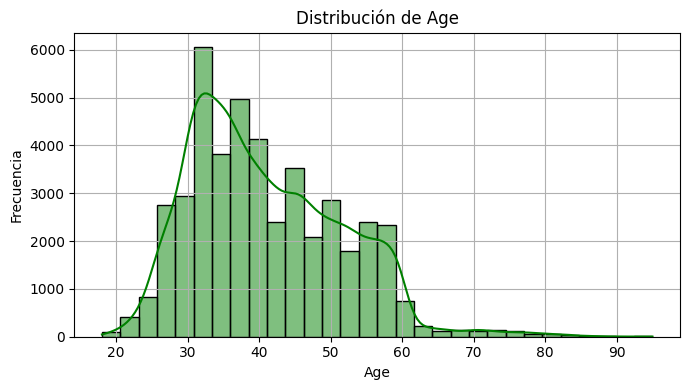

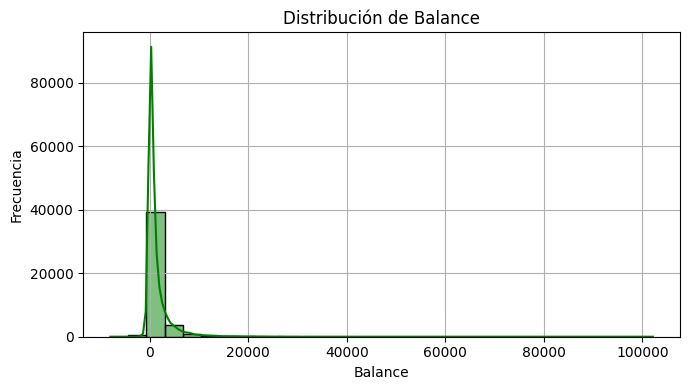

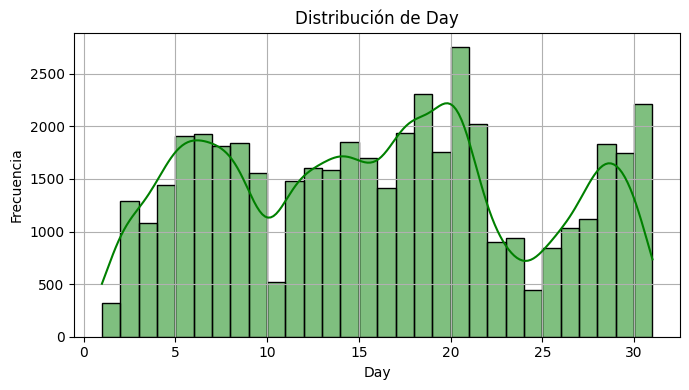

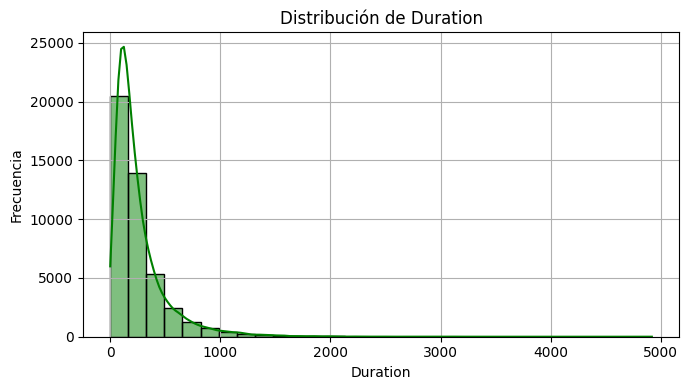

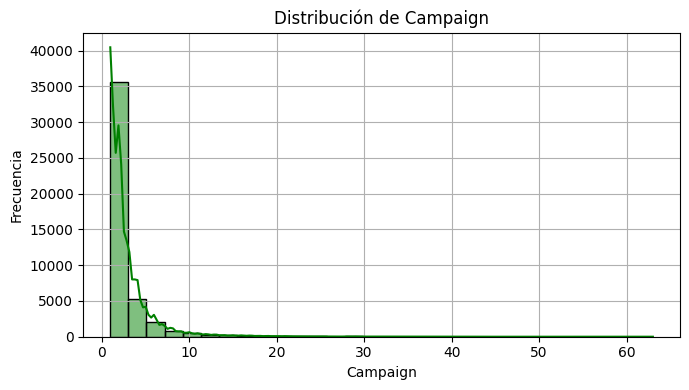

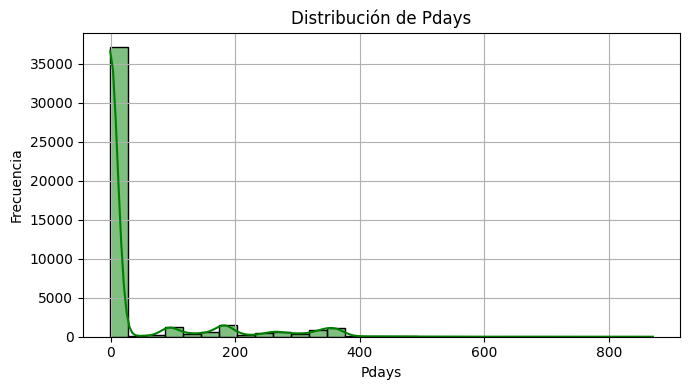

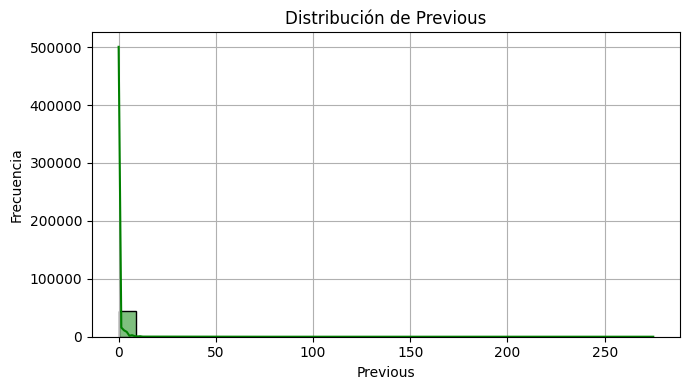

In [51]:
df_pandas = df01.select(colINT).toPandas()

# Graficar distribución de cada variable numérica
for col_int in colINT:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        df_pandas[col_int],
        bins=30,
        kde=True,
        color="green"
    )
    
    plt.ylabel("Frecuencia")
    plt.xlabel(col_int.capitalize())
    plt.title(f"Distribución de {col_int.capitalize()}")
    plt.grid()
    plt.tight_layout()
    plt.show()

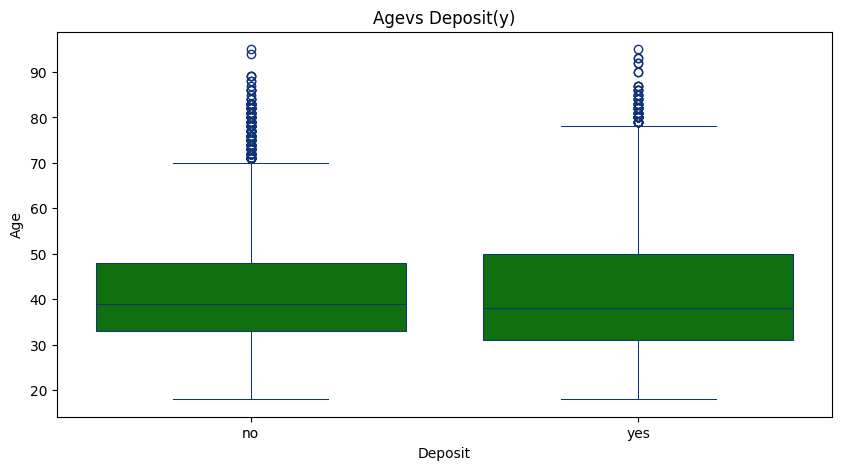

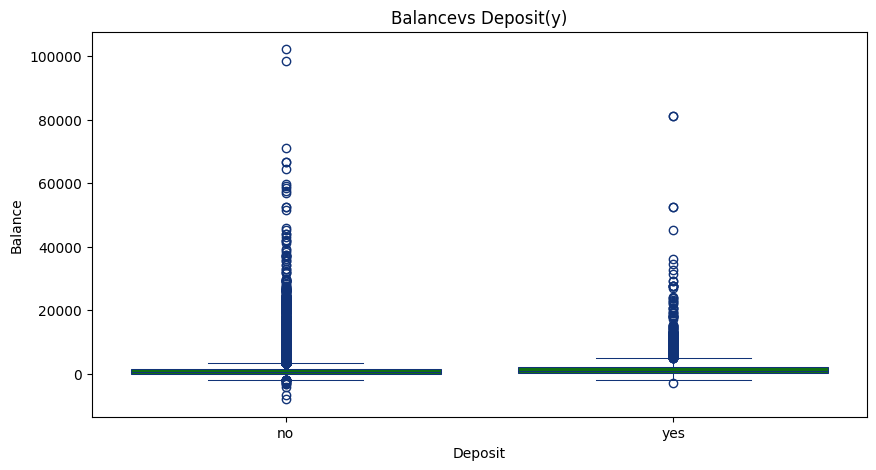

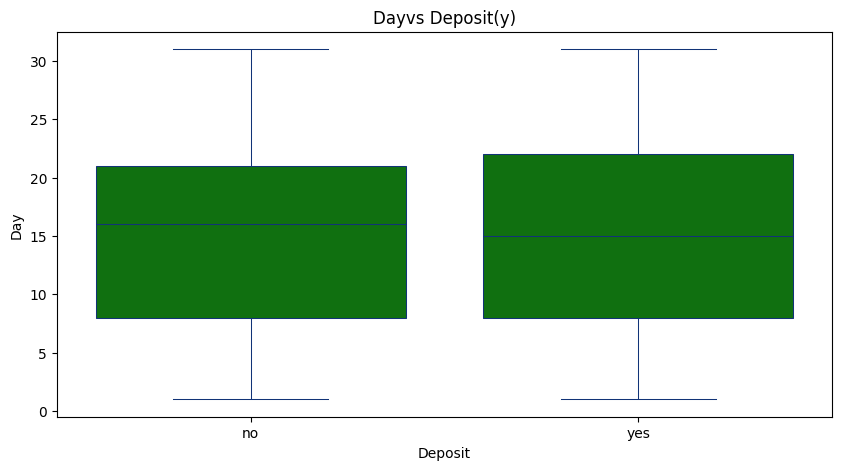

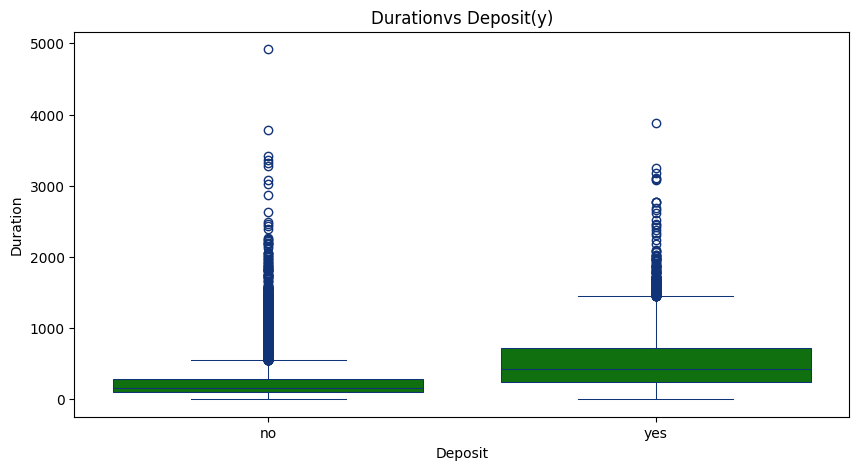

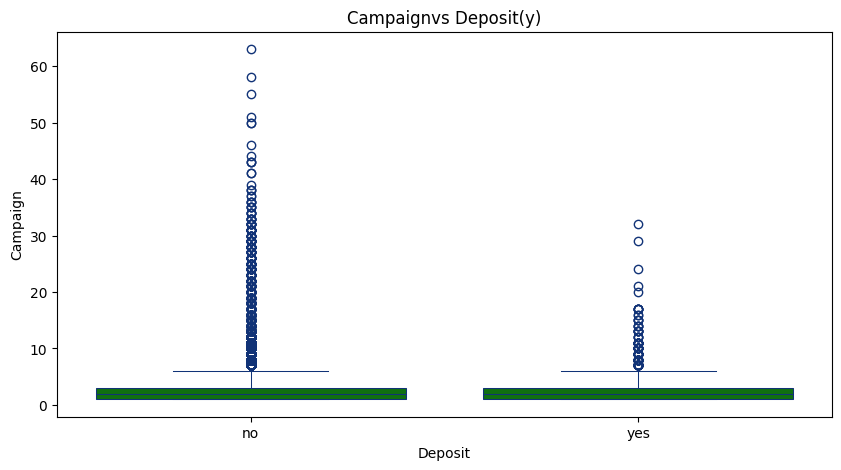

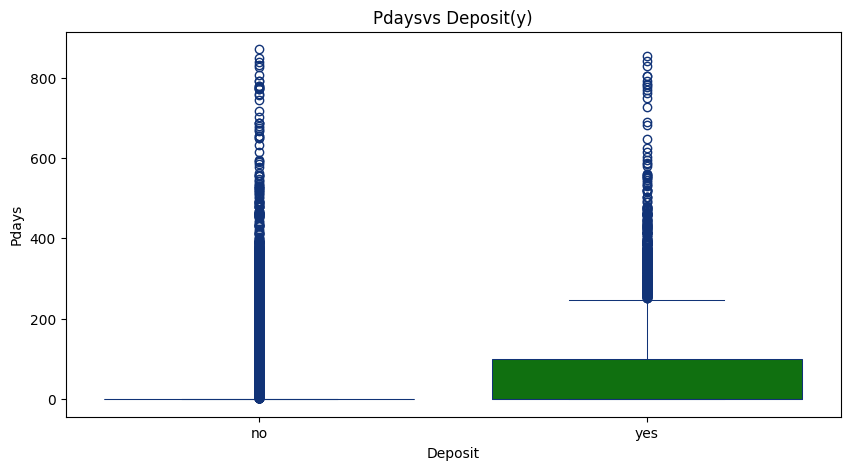

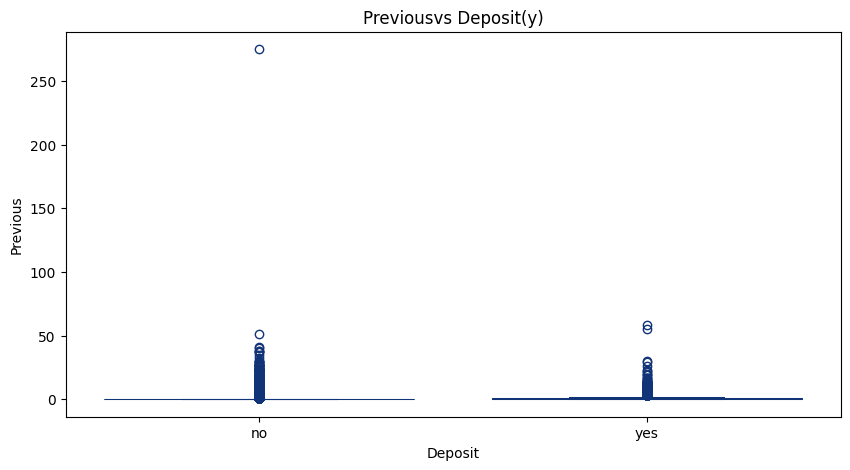

In [52]:
for col_int in colINT:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='y', y=col_int, color="green", linecolor="#137", linewidth=0.75, data=df01.toPandas())
    plt.ylabel(col_int.capitalize())
    plt.xlabel("Deposit")
    plt.title(f"{col_int.capitalize()}vs Deposit(y)")
    plt.show()

## 3.2. Correlación entre los Parámetros

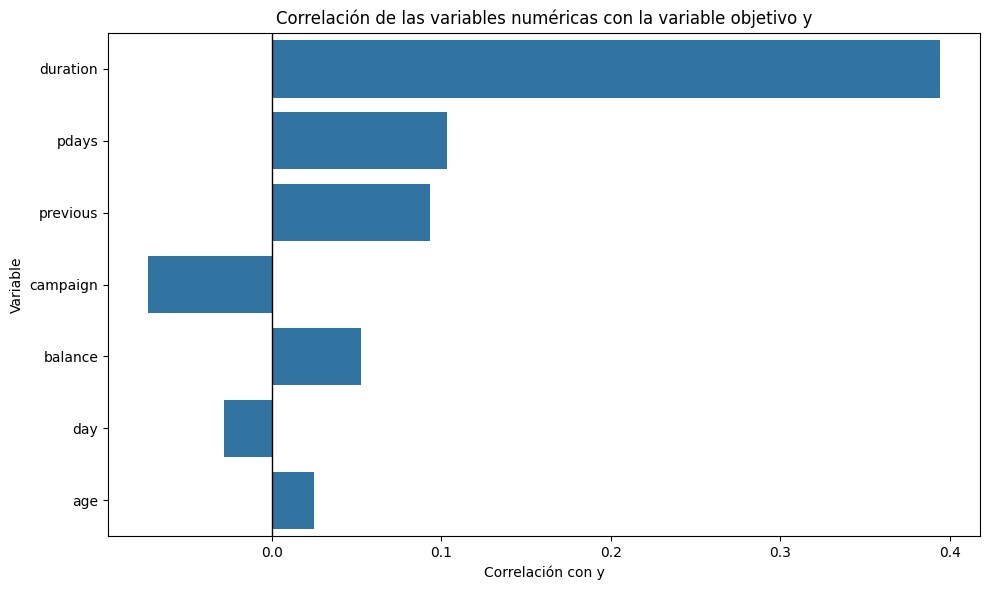

In [35]:
# Columnas numéricas + variable objetivo
columnas_corr = colINT + ["y"]

# Pasar de Spark a Pandas
df_corr = df01.select(columnas_corr).toPandas()

# Convertir variables numéricas
for col in colINT:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Convertir y de yes/no a 1/0
df_corr["y_num"] = df_corr["y"].map({
    "yes": 1,
    "no": 0
})

# Eliminar filas con valores nulos
df_corr = df_corr.dropna()

# Calcular correlación de cada variable con y_num
corr_y = df_corr[colINT + ["y_num"]].corr()["y_num"].drop("y_num")

# Ordenar por correlación absoluta
corr_y_ordenada = corr_y.reindex(
    corr_y.abs().sort_values(ascending=False).index
)

# Graficar
plt.figure(figsize=(10, 6))

sns.barplot(
    x=corr_y_ordenada.values,
    y=corr_y_ordenada.index
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Correlación de las variables numéricas con la variable objetivo y")
plt.xlabel("Correlación con y")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

- Recordar porque Duration aunque muestra una alta correlacion se deberia eliminar
- pday y previous pueden influir a favor, tambien se tiene que tener en cuenta los boxplots
- campaign tiene una influencia negativa
